In [1]:
from dask.distributed import LocalCluster, Client
cluster = LocalCluster()
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 12
Total threads: 96,Total memory: 0.98 TiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38227,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:33417,Total threads: 8
Dashboard: http://127.0.0.1:42131/status,Memory: 83.91 GiB
Nanny: tcp://127.0.0.1:44571,


### Load MITgcm Output from Assimilations

In [2]:
foldername = '/home/edavenport/analysis/yannai-waves/energy_flux/'

In [3]:
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 13
import cmocean.cm as cmo
import xarray as xr
from open_tpose import tpose2012to2013
import numpy as np
import xarray as xr

prefix = ['diag_state','diag_surf']
ds_tpose_noTAO = tpose2012to2013(prefix)

ds_tpose_noTAO['XC'] = ds_tpose_noTAO.XC.astype(float)
ds_tpose_noTAO['YC'] = ds_tpose_noTAO.YC.astype(float)
ds_tpose_noTAO['Z'] = ds_tpose_noTAO.Z.astype(float)
ds_tpose_noTAO['XG'] = ds_tpose_noTAO.XG.astype(float)
ds_tpose_noTAO['YG'] = ds_tpose_noTAO.YG.astype(float)

mar2013/diags_daily/
may2013/diags_daily/
jul2013/diags_daily/
sep2013/diags_daily/
nov2013/diags_daily/
Days in 2012-2013: (should be 731)
731


In [4]:
from xmitgcm import open_mdsdataset
data_dir = '/data/SO3/edavenport/tpose6/sep2012/velocity_assim/run_iter22/'
grid_dir = '/data/SO6/TPOSE_diags/tpose6/grid_6/'

offset = 10
num_diags = 30+31+offset #sep, oct + 10 days
itPerFile = 72 # 1 day
intervals = range(itPerFile,itPerFile*num_diags,itPerFile)

prefix = ['diag_state','diag_surf']
ds = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-09-01',delta_t=1200)

num_diags = 30+31+offset# nov, dec (starting from nov 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/nov2012/run_iter20/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-11-01',delta_t=1200)

ds_tpose_TAO = xr.concat([ds,ds_new],dim='time')

num_diags = 31+28+31 # jan, feb, mar (starting from jan 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/jan2013/run_iter14/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2013-01-01',delta_t=1200)

ds_tpose_TAO = xr.concat([ds_tpose_TAO,ds_new],dim='time')

ds_tpose_TAO['XC'] = ds_tpose_TAO.XC.astype(float)
ds_tpose_TAO['YC'] = ds_tpose_TAO.YC.astype(float)
ds_tpose_TAO['Z'] = ds_tpose_TAO.Z.astype(float)
ds_tpose_TAO['XG'] = ds_tpose_TAO.XG.astype(float)
ds_tpose_TAO['YG'] = ds_tpose_TAO.YG.astype(float)

In [5]:
ds_tpose_noTAO = ds_tpose_noTAO.sel(time=slice('2012-09-01','2013-04-01'))

In [100]:
lon = 250
lon_str = '110'

### Compute Density Anomaly

In [101]:
import gsw

In [102]:
p = gsw.p_from_z(ds_tpose_TAO.Z, 0.0) # convert these to pressure at the equator
SA = gsw.SA_from_SP(ds_tpose_TAO.SALT.sel(XC=lon,YC=0.0,method='nearest'), p, ds_tpose_TAO.SALT.sel(XC=lon,YC=0.0,method='nearest').XC, 0.0)
CT = gsw.CT_from_pt(SA, ds_tpose_TAO.THETA.sel(XC=lon,YC=0.0,method='nearest'))
rho = gsw.rho(SA, CT, p)

In [103]:
temp = ds_tpose_TAO.THETA.sel(XC=lon,YC=0.0,method='nearest').copy(deep=True)
temp.values = rho
rho = temp

temp = ds_tpose_TAO.THETA.sel(XC=lon,YC=0.0,method='nearest').copy(deep=True)
temp.values = SA
SA = temp

temp = ds_tpose_TAO.THETA.sel(XC=lon,YC=0.0,method='nearest').copy(deep=True)
temp.values = CT
CT = temp


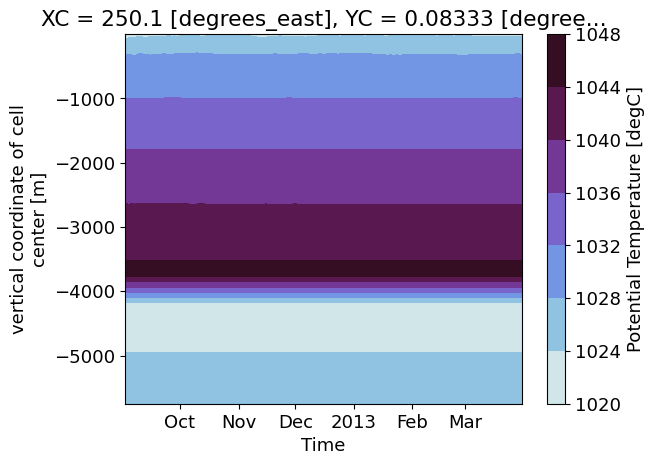

In [104]:
rho.plot.contourf(y='Z',cmap=cmo.dense)

In [105]:
import numpy as np
import gsw  # TEOS-10, optional if using MITgcm EOS

# Constants
rho0 = 1035.0  # reference density
g = 9.81       # gravity

# THETA, SALT: shape (time, z, y, x)
# ETAN: shape (time, y, x)
# dz: shape (z,)

# # 1. Compute in-situ density
# # Use simple linear EOS (Boussinesq) or gsw
# alpha = 2e-4  # thermal expansion coefficient [1/K]
# beta  = 7.6e-4 # haline contraction coefficient [1/psu]
# theta0 = 10.0  # reference potential temperature
# salt0  = 35.0  # reference salinity

# rho = rho0 * (1 - alpha * (ds_tpose_TAO.THETA.sel(XC=lon,YC=0.0,method='nearest') - theta0) + beta * (ds_tpose_TAO.SALT.sel(XC=lon,YC=0.0,method='nearest') - salt0))
p = gsw.p_from_z(ds_tpose_TAO.Z, 0.0) # convert these to pressure at the equator
SA = gsw.SA_from_SP(ds_tpose_TAO.SALT.sel(XC=lon,YC=0.0,method='nearest'), p, ds_tpose_TAO.SALT.sel(XC=lon,YC=0.0,method='nearest').XC, 0.0)
CT = gsw.CT_from_pt(SA, ds_tpose_TAO.THETA.sel(XC=lon,YC=0.0,method='nearest'))
rho = gsw.rho(SA, CT, p)

temp = ds_tpose_TAO.THETA.sel(XC=lon,YC=0.0,method='nearest').copy(deep=True)
temp.values = rho
rho = temp

rho = rho.where(ds_tpose_TAO.sel(XC=lon,YC=0.0,method='nearest').maskC)

# 2. Buoyancy anomaly
b = - g * (rho - rho0) / rho0  # shape (z,y,x)

# 3. Integrate hydrostatic pressure from surface down
# multiply b by drF first (broadcasting)
b_dr = b * ds_tpose_TAO.drF  # shape (time, z)


In [106]:
# cumulative sum along vertical axis
phi_hydro = np.cumsum(b_dr, axis=1)

# add surface contribution everywhere 
phi_hydro += g * ds_tpose_TAO.ETAN.sel(XC=lon,YC=0.0,method='nearest') 

p_prime = rho0 * phi_hydro

In [107]:
phi_hydro

<xarray.DataArray (time: 211, Z: 66)> Size: 111kB
dask.array<add, shape=(211, 66), dtype=float64, chunksize=(1, 66), chunktype=numpy.ndarray>
Coordinates: (12/14)
  * time     (time) datetime64[ns] 2kB 2012-09-02 2012-09-03 ... 2013-03-31
  * Z        (Z) float64 528B -1.0 -3.0 -5.0 ... -4.75e+03 -5.25e+03 -5.75e+03
    XC       float64 8B 250.1
    YC       float64 8B 0.08333
    rA       >f4 4B dask.array<chunksize=(), meta=np.ndarray>
    Depth    >f4 4B dask.array<chunksize=(), meta=np.ndarray>
    ...       ...
    hFacC    (Z) >f4 264B dask.array<chunksize=(66,), meta=np.ndarray>
    maskC    (Z) bool 66B dask.array<chunksize=(66,), meta=np.ndarray>
    dxF      >f4 4B dask.array<chunksize=(), meta=np.ndarray>
    rhoRef   (Z) >f4 264B dask.array<chunksize=(66,), meta=np.ndarray>
    dyF      >f4 4B dask.array<chunksize=(), meta=np.ndarray>
    iter     (time) int64 2kB dask.array<chunksize=(1,), meta=np.ndarray>

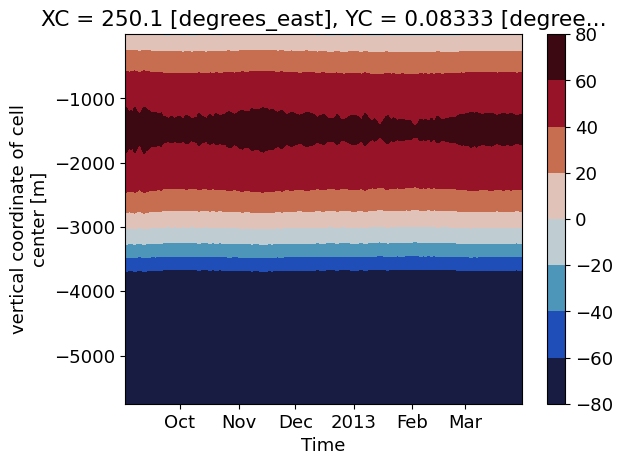

In [108]:
phi_hydro.plot.contourf(y='Z',cmap=cmo.balance)

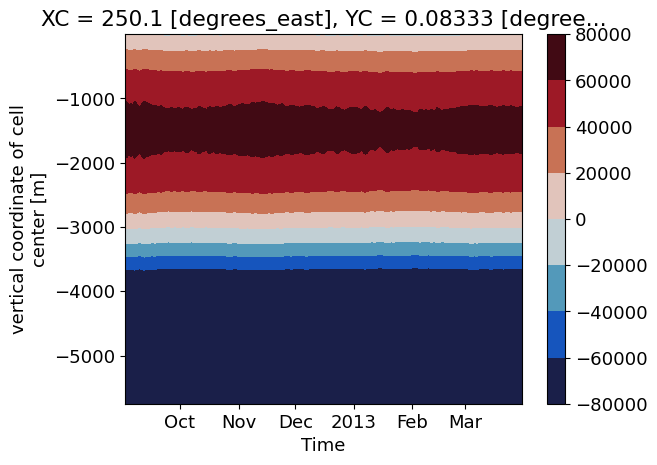

In [109]:
p_prime.plot.contourf(y='Z',cmap=cmo.balance)

In [110]:
from scipy.signal import butter, sosfiltfilt, detrend
# bandpass density (before reconstructing pressure)

# filtering out high frequency changes
fs = 1/86400 # sampling rate is 1 day (86400 seconds per day)
highF = (1/30)*fs #  
lowF = (1/60)*fs #  
cutoff = np.array([lowF, highF])
order = 4
sos = butter(order, cutoff, 'bandpass', fs=fs, output='sos')

uvel = detrend(ds_tpose_TAO.UVEL.sel(XG=lon,YC=0.0,method='nearest'),axis=0)
uvel_anom = uvel - uvel.mean(axis=0)
vvel = detrend(ds_tpose_TAO.VVEL.sel(XC=lon,YG=0.0,method='nearest'),axis=0)
vvel_anom = vvel - vvel.mean(axis=0)
wvel = detrend(ds_tpose_TAO.WVEL.sel(XC=lon,YC=0.0,method='nearest'),axis=0)
wvel_anom = wvel - wvel.mean(axis=0)

p_prime_bandpass = sosfiltfilt(sos, detrend(p_prime,axis=0), axis=0)
uvel_prime = sosfiltfilt(sos, uvel_anom, axis=0)
vvel_prime = sosfiltfilt(sos, vvel_anom, axis=0)
wvel_prime = sosfiltfilt(sos, wvel_anom, axis=0)

In [111]:
temp = rho.copy(deep=True)
temp.data = p_prime_bandpass
p_prime_bandpass = temp

temp = ds_tpose_TAO.UVEL.sel(XG=lon,YC=0.0,method='nearest').copy(deep=True)
temp.data = uvel_prime
uvel_prime = temp

temp = ds_tpose_TAO.VVEL.sel(XC=lon,YG=0.0,method='nearest').copy(deep=True)
temp.data = vvel_prime
vvel_prime = temp

temp = ds_tpose_TAO.WVEL.sel(XC=lon,YC=0.0,method='nearest').copy(deep=True)
temp.data = wvel_prime
wvel_prime = temp

p_prime = p_prime_bandpass.where(ds_tpose_TAO.maskC.sel(XC=lon,YC=0.0,method='nearest'))

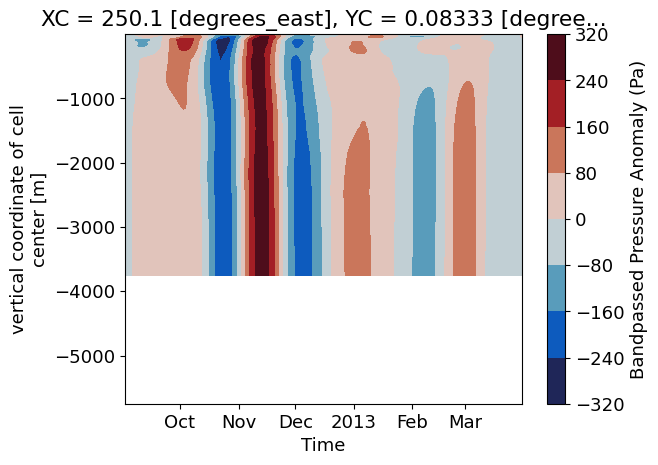

In [112]:
p_prime.plot.contourf(y='Z',cmap=cmo.balance,cbar_kwargs={'label':'Bandpassed Pressure Anomaly (Pa)'})

In [113]:
# # velocity fluctuations
# u_prime = uvel_bandpass - uvel_bandpass.mean(dim="time")
# v_prime = vvel_bandpass - vvel_bandpass.mean(dim="time")
# w_prime = wvel_bandpass - wvel_bandpass.mean(dim="time")

In [114]:
import xgcm
grid = xgcm.Grid(ds_tpose_TAO, periodic=['X','Y'])
w_prime_interp = grid.interp(wvel_prime, 'Z', boundary='fill')
Fx = (p_prime * uvel_prime).mean(dim="time")
Fy = (p_prime * vvel_prime).mean(dim="time")
Fz = (p_prime * w_prime_interp).mean(dim="time")

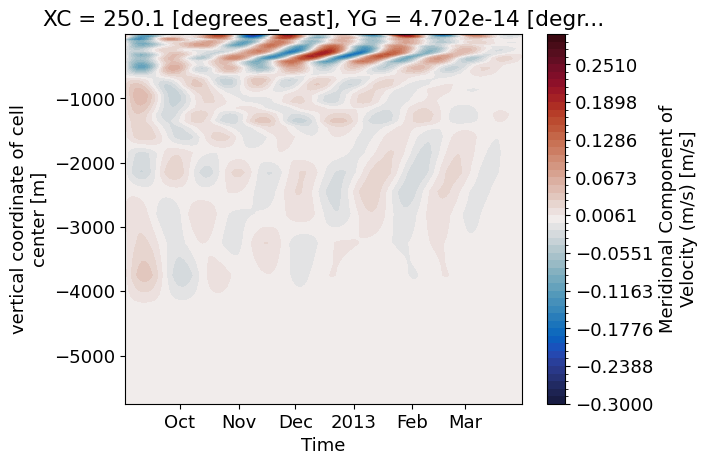

In [115]:
levels = np.linspace(-0.3,0.3,50)
vvel_prime.plot.contourf(y='Z',cmap=cmo.balance,levels=levels)

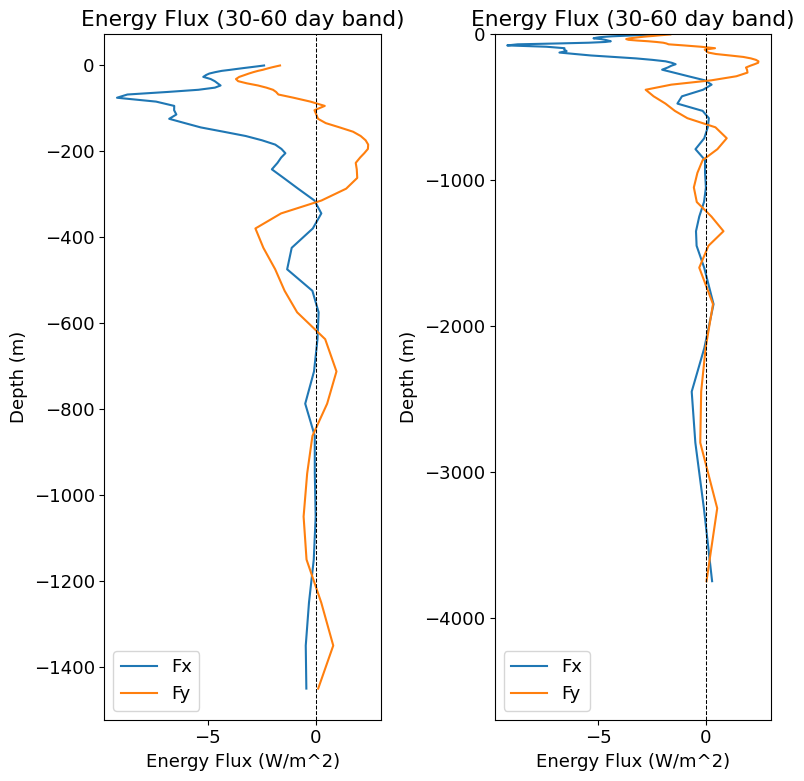

In [116]:
fig, ax = plt.subplots(figsize=(8,8),ncols=2)

Fx.sel(Z=slice(0,-1500)).plot(ax=ax[0],y='Z',label='Fx')
Fy.sel(Z=slice(0,-1500)).plot(ax=ax[0],y='Z',label='Fy')
# Fz.plot(ax=ax,y='Z',label='Fz')
ax[0].legend()
ax[0].set_title('Energy Flux (30-60 day band)')
ax[0].set_xlabel('Energy Flux (W/m^2)')
ax[0].set_ylabel('Depth (m)')
# ax[0].axhline(-120,color='k',ls='--',lw=0.75)
# ax[0].axhline(-600,color='k',ls='--',lw=0.75)
ax[0].axvline(0,color='k',ls='--',lw=0.75)

Fx.plot(ax=ax[1],y='Z',label='Fx')
Fy.plot(ax=ax[1],y='Z',label='Fy')
# Fz.plot(ax=ax,y='Z',label='Fz')
ax[1].legend()
ax[1].set_title('Energy Flux (30-60 day band)')
ax[1].set_xlabel('Energy Flux (W/m^2)')
ax[1].set_ylabel('Depth (m)')
# ax[1].axhline(-120,color='k',ls='--',lw=0.75)
# ax[1].axhline(-600,color='k',ls='--',lw=0.75)
ax[1].axvline(0,color='k',ls='--',lw=0.75)
ax[1].set_ylim(-4700,0)
plt.tight_layout()
fig.savefig(foldername + 'energy_flux_profiles_'+ lon_str + '.png',dpi=300)

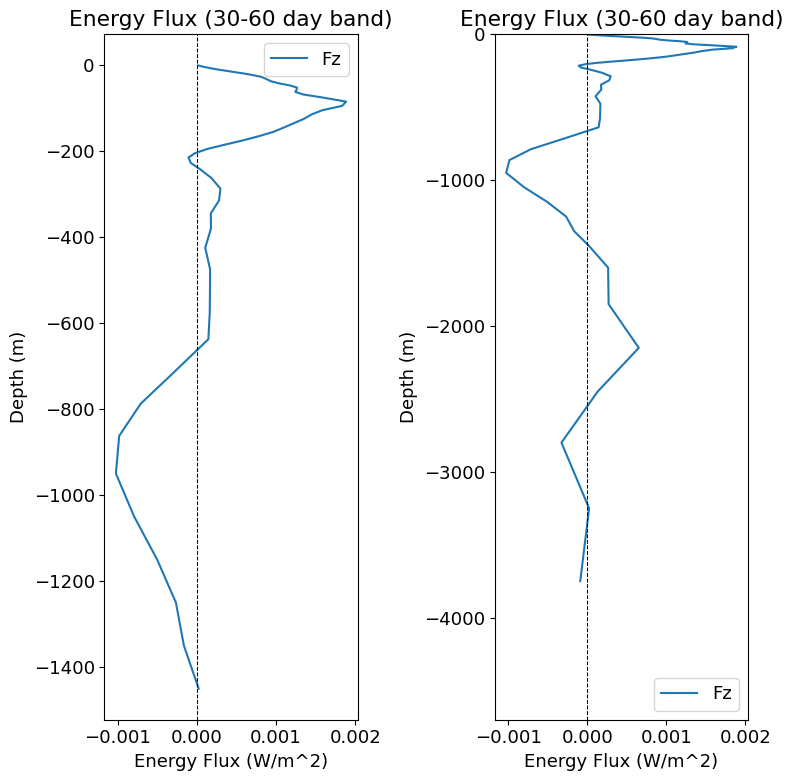

In [117]:
fig, ax = plt.subplots(figsize=(8,8),ncols=2)

Fz.sel(Z=slice(0,-1500)).plot(ax=ax[0],y='Z',label='Fz')
ax[0].legend()
ax[0].set_title('Energy Flux (30-60 day band)')
ax[0].set_xlabel('Energy Flux (W/m^2)')
ax[0].set_ylabel('Depth (m)')
# ax[0].axhline(-120,color='k',ls='--',lw=0.75)
# ax[0].axhline(-600,color='k',ls='--',lw=0.75)
ax[0].axvline(0,color='k',ls='--',lw=0.75)

Fz.plot(ax=ax[1],y='Z',label='Fz')
ax[1].legend()
ax[1].set_title('Energy Flux (30-60 day band)')
ax[1].set_xlabel('Energy Flux (W/m^2)')
ax[1].set_ylabel('Depth (m)')
# ax[1].axhline(-120,color='k',ls='--',lw=0.75)
# ax[1].axhline(-600,color='k',ls='--',lw=0.75)
ax[1].axvline(0,color='k',ls='--',lw=0.75)
ax[1].set_ylim(-4700,0)
plt.tight_layout()
fig.savefig(foldername + 'Fz_profiles_'+ lon_str + '.png',dpi=300)

### Repeat without TAO assimilation

In [118]:
p = gsw.p_from_z(ds_tpose_noTAO.Z, 0.0) # convert these to pressure at the equator
SA = gsw.SA_from_SP(ds_tpose_noTAO.SALT.sel(XC=lon,YC=0.0,method='nearest'), p, ds_tpose_noTAO.SALT.sel(XC=lon,YC=0.0,method='nearest').XC, 0.0)
CT = gsw.CT_from_pt(SA, ds_tpose_noTAO.THETA.sel(XC=lon,YC=0.0,method='nearest'))
rho = gsw.rho(SA, CT, p)

temp = ds_tpose_noTAO.THETA.sel(XC=lon,YC=0.0,method='nearest').copy(deep=True)
temp.values = rho
rho = temp

rho = rho.where(ds_tpose_noTAO.sel(XC=lon,YC=0.0,method='nearest').maskC)

# 2. Buoyancy anomaly
b = - g * (rho - rho0) / rho0  # shape (z,y,x)

# 3. Integrate hydrostatic pressure from surface down
# multiply b by drF first (broadcasting)
b_dr = b * ds_tpose_noTAO.drF  # shape (time, z)

# cumulative sum along vertical axis
phi_hydro = np.cumsum(b_dr, axis=1)

# add surface contribution everywhere 
phi_hydro += g * ds_tpose_noTAO.ETAN.sel(XC=lon,YC=0.0,method='nearest') 

p_prime = rho0 * phi_hydro

uvel = detrend(ds_tpose_noTAO.UVEL.sel(XG=lon,YC=0.0,method='nearest'),axis=0)
uvel_anom = uvel - uvel.mean(axis=0)
vvel = detrend(ds_tpose_noTAO.VVEL.sel(XC=lon,YG=0.0,method='nearest'),axis=0)
vvel_anom = vvel - vvel.mean(axis=0)
wvel = detrend(ds_tpose_noTAO.WVEL.sel(XC=lon,YC=0.0,method='nearest'),axis=0)
wvel_anom = wvel - wvel.mean(axis=0)

p_prime_bandpass = sosfiltfilt(sos, detrend(p_prime,axis=0), axis=0)
uvel_prime = sosfiltfilt(sos, uvel_anom, axis=0)
vvel_prime = sosfiltfilt(sos, vvel_anom, axis=0)
wvel_prime = sosfiltfilt(sos, wvel_anom, axis=0)

temp = rho.copy(deep=True)
temp.data = p_prime_bandpass
p_prime_bandpass = temp

temp = ds_tpose_noTAO.UVEL.sel(XG=lon,YC=0.0,method='nearest').copy(deep=True)
temp.data = uvel_prime
uvel_prime = temp

temp = ds_tpose_noTAO.VVEL.sel(XC=lon,YG=0.0,method='nearest').copy(deep=True)
temp.data = vvel_prime
vvel_prime = temp

temp = ds_tpose_noTAO.WVEL.sel(XC=lon,YC=0.0,method='nearest').copy(deep=True)
temp.data = wvel_prime
wvel_prime = temp

p_prime = p_prime_bandpass.where(ds_tpose_noTAO.maskC.sel(XC=lon,YC=0.0,method='nearest'))

In [119]:
grid = xgcm.Grid(ds_tpose_noTAO, periodic=['X','Y'])
w_prime_interp = grid.interp(wvel_prime, 'Z', boundary='fill')
Fx_noTAO = (p_prime * uvel_prime).mean(dim="time")
Fy_noTAO = (p_prime * vvel_prime).mean(dim="time")
Fz_noTAO = (p_prime * w_prime_interp).mean(dim="time")

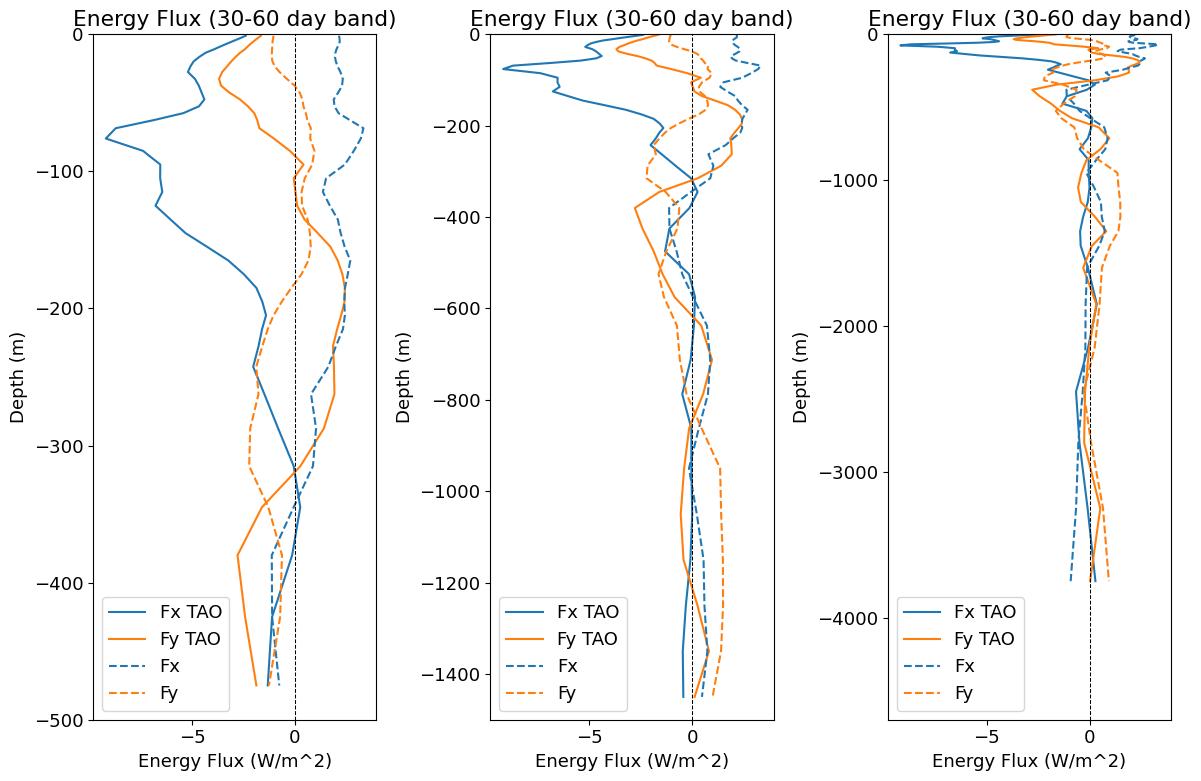

In [120]:
fig, ax = plt.subplots(figsize=(12,8),ncols=3)

Fx.sel(Z=slice(0,-500)).plot(ax=ax[0],y='Z',label='Fx TAO',color='tab:blue')
Fy.sel(Z=slice(0,-500)).plot(ax=ax[0],y='Z',label='Fy TAO',color='tab:orange')
Fx_noTAO.sel(Z=slice(0,-500)).plot(ax=ax[0],y='Z',label='Fx',ls='--',color='tab:blue')
Fy_noTAO.sel(Z=slice(0,-500)).plot(ax=ax[0],y='Z',label='Fy',ls='--',color='tab:orange')
ax[0].legend()
ax[0].set_title('Energy Flux (30-60 day band)')
ax[0].set_xlabel('Energy Flux (W/m^2)')
ax[0].set_ylabel('Depth (m)')
# ax[0].axhline(-120,color='k',ls='--',lw=0.75)
ax[0].axvline(0,color='k',ls='--',lw=0.75)
ax[0].set_ylim(-500,0)

Fx.sel(Z=slice(0,-1500)).plot(ax=ax[1],y='Z',label='Fx TAO',color='tab:blue')
Fy.sel(Z=slice(0,-1500)).plot(ax=ax[1],y='Z',label='Fy TAO',color='tab:orange')
Fx_noTAO.sel(Z=slice(0,-1500)).plot(ax=ax[1],y='Z',label='Fx',ls='--',color='tab:blue')
Fy_noTAO.sel(Z=slice(0,-1500)).plot(ax=ax[1],y='Z',label='Fy',ls='--',color='tab:orange')
ax[1].legend()
ax[1].set_title('Energy Flux (30-60 day band)')
ax[1].set_xlabel('Energy Flux (W/m^2)')
ax[1].set_ylabel('Depth (m)')
# ax[1].axhline(-120,color='k',ls='--',lw=0.75)
# ax[1].axhline(-600,color='k',ls='--',lw=0.75)
ax[1].axvline(0,color='k',ls='--',lw=0.75)
ax[1].set_ylim(-1500,0)

Fx.plot(ax=ax[2],y='Z',label='Fx TAO',color='tab:blue')
Fy.plot(ax=ax[2],y='Z',label='Fy TAO',color='tab:orange')
Fx_noTAO.plot(ax=ax[2],y='Z',label='Fx',ls='--',color='tab:blue')
Fy_noTAO.plot(ax=ax[2],y='Z',label='Fy',ls='--',color='tab:orange')
ax[2].legend()
ax[2].set_title('Energy Flux (30-60 day band)')
ax[2].set_xlabel('Energy Flux (W/m^2)')
ax[2].set_ylabel('Depth (m)')
# ax[2].axhline(-120,color='k',ls='--',lw=0.75)
# ax[2].axhline(-600,color='k',ls='--',lw=0.75)
ax[2].axvline(0,color='k',ls='--',lw=0.75)
ax[2].set_ylim(-4700,0)
plt.tight_layout()
fig.savefig(foldername + 'energy_flux_profiles_compare_'+ lon_str + '.png',dpi=300)

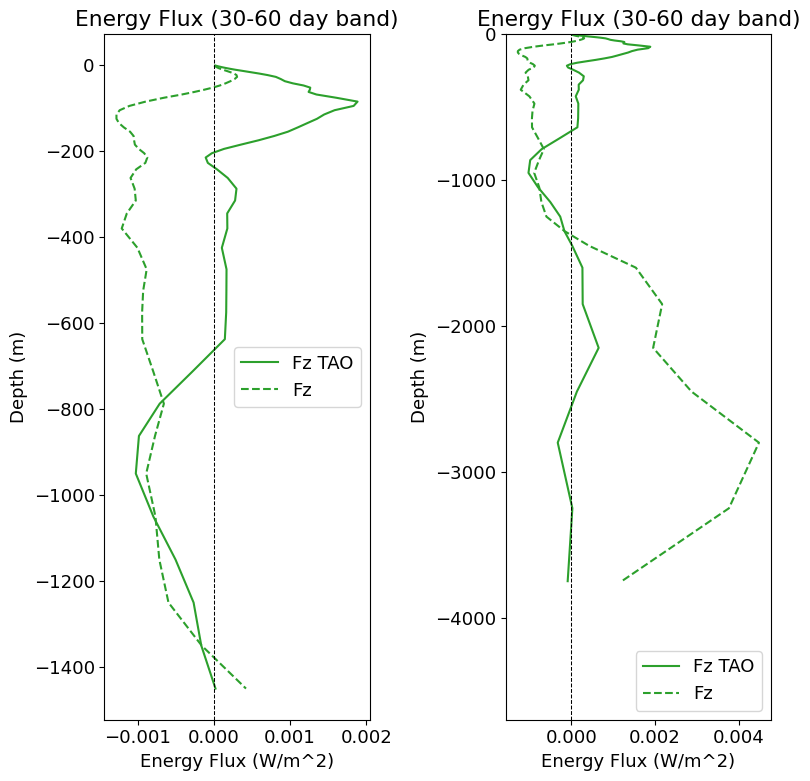

In [121]:
fig, ax = plt.subplots(figsize=(8,8),ncols=2)

Fz.sel(Z=slice(0,-1500)).plot(ax=ax[0],y='Z',label='Fz TAO',color='tab:green')
Fz_noTAO.sel(Z=slice(0,-1500)).plot(ax=ax[0],y='Z',label='Fz',ls='--',color='tab:green')
ax[0].legend()
ax[0].set_title('Energy Flux (30-60 day band)')
ax[0].set_xlabel('Energy Flux (W/m^2)')
ax[0].set_ylabel('Depth (m)')
# ax[0].axhline(-120,color='k',ls='--',lw=0.75)
# ax[0].axhline(-600,color='k',ls='--',lw=0.75)
ax[0].axvline(0,color='k',ls='--',lw=0.75)

Fz.plot(ax=ax[1],y='Z',label='Fz TAO',color='tab:green')
Fz_noTAO.plot(ax=ax[1],y='Z',label='Fz',ls='--',color='tab:green')
ax[1].legend()
ax[1].set_title('Energy Flux (30-60 day band)')
ax[1].set_xlabel('Energy Flux (W/m^2)')
ax[1].set_ylabel('Depth (m)')
# ax[1].axhline(-120,color='k',ls='--',lw=0.75)
# ax[1].axhline(-600,color='k',ls='--',lw=0.75)
ax[1].axvline(0,color='k',ls='--',lw=0.75)
ax[1].set_ylim(-4700,0)
plt.tight_layout()
fig.savefig(foldername + 'Fz_profiles_compare_'+ lon_str + '.png',dpi=300)

### Map of Integrated Energy Flux

In [67]:
from scipy.signal import butter, sosfiltfilt, detrend
# compute the energy flux for a lat/lon box (not just a point)
lat_min = -5
lat_max = 5
lon_min = 180
lon_max = 260

# filtering
fs = 1/86400 # sampling rate is 1 day (86400 seconds per day)
highF = (1/30)*fs #  
lowF = (1/60)*fs #  
cutoff = np.array([lowF, highF])
order = 4
sos = butter(order, cutoff, 'bandpass', fs=fs, output='sos')

p = gsw.p_from_z(ds_tpose_TAO.Z, 0.0) # convert these to pressure at the equator
SA = gsw.SA_from_SP(ds_tpose_TAO.SALT.sel(XC=slice(lon_min,lon_max),YC=slice(lat_min,lat_max)), p, ds_tpose_TAO.SALT.sel(XC=slice(lon_min,lon_max),YC=slice(lat_min,lat_max)).XC, 0.0)
CT = gsw.CT_from_pt(SA, ds_tpose_TAO.THETA.sel(XC=slice(lon_min,lon_max),YC=slice(lat_min,lat_max)))
rho = gsw.rho(SA, CT, p)

temp = ds_tpose_TAO.THETA.sel(XC=slice(lon_min,lon_max),YC=slice(lat_min,lat_max)).copy(deep=True)
temp.values = rho
rho = temp

temp = ds_tpose_TAO.THETA.sel(XC=slice(lon_min,lon_max),YC=slice(lat_min,lat_max)).copy(deep=True)
temp.values = SA
SA = temp

temp = ds_tpose_TAO.THETA.sel(XC=slice(lon_min,lon_max),YC=slice(lat_min,lat_max)).copy(deep=True)
temp.values = CT
CT = temp

rho_bandpass = sosfiltfilt(sos, detrend(rho,axis=0), axis=0)
uvel_bandpass = sosfiltfilt(sos, detrend(ds_tpose_TAO.UVEL.sel(XG=slice(lon_min,lon_max),YC=slice(lat_min,lat_max)),axis=0), axis=0)
vvel_bandpass = sosfiltfilt(sos, detrend(ds_tpose_TAO.VVEL.sel(XC=slice(lon_min,lon_max),YG=slice(lat_min,lat_max)),axis=0), axis=0)
wvel_bandpass = sosfiltfilt(sos, detrend(ds_tpose_TAO.WVEL.sel(XC=slice(lon_min,lon_max),YC=slice(lat_min,lat_max)),axis=0), axis=0)

temp = rho.copy(deep=True)
temp.data = rho_bandpass
rho_bandpass = temp

temp = ds_tpose_TAO.UVEL.sel(XG=slice(lon_min,lon_max),YC=slice(lat_min,lat_max)).copy(deep=True)
temp.data = uvel_bandpass
uvel_bandpass = temp

temp = ds_tpose_TAO.VVEL.sel(XC=slice(lon_min,lon_max),YG=slice(lat_min,lat_max)).copy(deep=True)
temp.data = vvel_bandpass
vvel_bandpass = temp

temp = ds_tpose_TAO.WVEL.sel(XC=slice(lon_min,lon_max),YC=slice(lat_min,lat_max)).copy(deep=True)
temp.data = wvel_bandpass
wvel_bandpass = temp

rho = rho.where(ds_tpose_TAO.maskC.sel(XC=slice(lon_min,lon_max),YC=slice(lat_min,lat_max)))
rho_bandpass = rho_bandpass.where(ds_tpose_TAO.maskC.sel(XC=slice(lon_min,lon_max),YC=slice(lat_min,lat_max)))

In [68]:
g = 9.81 
rho_bar = rho_bandpass.mean(dim="time")

rho_prime = rho_bandpass - rho_bar

# multiply by layer thickness
integrand = rho_prime * ds_tpose_TAO.drF

# reverse vertical axis so cumulative sum integrates upward
integrand_rev = integrand.isel(Z=slice(None, None, -1))

# cumulative sum
p_prime_rev = g * integrand_rev.cumsum(dim="Z")

# flip back
p_prime = p_prime_rev.isel(Z=slice(None, None, -1))

p_prime = p_prime - p_prime.isel(Z=0)
temp = ds_tpose_TAO.THETA.sel(XC=slice(lon_min,lon_max),YC=slice(lat_min,lat_max)).copy(deep=True)
temp.values = p_prime
p_prime = temp

In [69]:
u_prime = uvel_bandpass - uvel_bandpass.mean(dim="time")
v_prime = vvel_bandpass - vvel_bandpass.mean(dim="time")
w_prime = wvel_bandpass - wvel_bandpass.mean(dim="time")

In [70]:
import xgcm 
ds_crop = ds_tpose_TAO.sel(YC=slice(lat_min, lat_max), XC=slice(lon_min, lon_max),YG=slice(lat_min, lat_max), XG=slice(lon_min, lon_max))
grid_crop = xgcm.Grid(ds_crop, periodic=False)  # usually False for subset
w_prime_interp = grid_crop.interp(w_prime, 'Z', boundary='fill')
u_prime_interp = grid_crop.interp(u_prime, 'X', boundary='fill')
v_prime_interp = grid_crop.interp(v_prime, 'Y', boundary='fill')

In [71]:
Fx = (p_prime * u_prime_interp).mean(dim="time")
Fy = (p_prime * v_prime_interp).mean(dim="time")
Fz = (p_prime * w_prime_interp).mean(dim="time")

In [72]:
# integrate the energy flux from the surface to the bottom to get the total energy flux convergence into the column
# energy_flux_convergence = -(Fx.differentiate('XC') + Fy.differentiate('YC') + Fz.differentiate('Z')).cumsum(dim='Z')
Fx_cumsum = Fx.cumsum('Z')
Fy_cumsum = Fy.cumsum('Z')
Fz_cumsum = Fz.cumsum('Z')

In [75]:
F_column = (Fz * ds_tpose_TAO.drF).sum(dim='Z') / ds_tpose_TAO.drF.sum(dim='Z')

/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/distributed/client.py:3374: UserWarning: Sending large graph of size 5.98 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


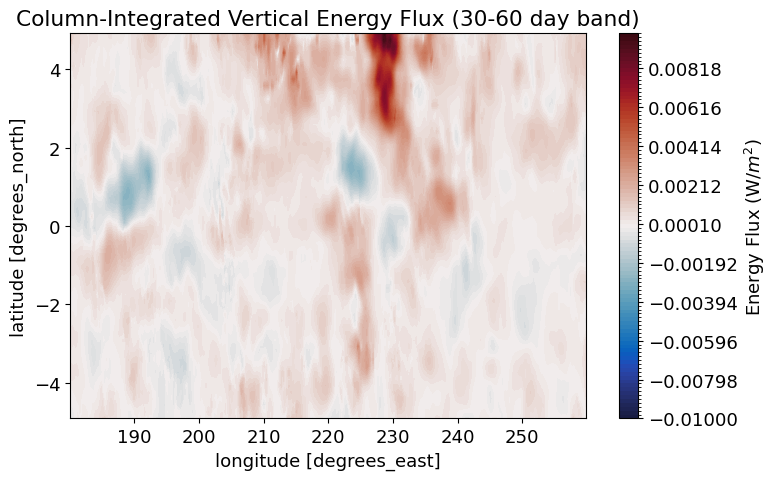

In [77]:
fig,ax = plt.subplots(figsize=(8,5))
levels = np.linspace(-0.01,0.01,100)
F_column.plot.contourf(ax=ax,levels=levels,cmap=cmo.balance, y='YC', cbar_kwargs={'label': 'Energy Flux (W/$m^2$)'})
ax.set_title('Column-Integrated Vertical Energy Flux (30-60 day band)')
plt.tight_layout()
fig.savefig(foldername + 'EnergyFlux_vertical_map.png',dpi=300)

In [ ]:
client.shutdown()
cluster.close()
client.close()